# Education and Gaming, does it affect you?

This is a dataset retireved from [kaggle.com](https://www.kaggle.com/datasets/aiexplorer77/gaming-vs-academic-performance) which show students and the relationship their studies have to their hobbies in this case video game and social media. NOTE: This dataset is entirely generated using fictional data and is only meant for people like me to practice data analysis and presenting data as it's given. Any conclusions given using this dataset should be taken with a grain of salt as non of the answers given are from a human. The dataset is setup to simulate an enviroment where students, ages 16 to 24, tells us about their online, social, sleeping and study habits. Aswell shows us the academics activies of the students with their grades and attendance.

---
---

## Intro

**For this notebook we are gonna try and answer the following questions:**
- Is there any correlation between gaming addiciton and fault grades?
- Are there any other factors that might affect school performance(Lack of sleep, Not enough time spent studying, Low Attendance)?
- What is the gaming patterns between the different genders?
- Are certain genres of games more addictive than others?

Below is all the necessary libraries used during the making of this notebook as well as the chosen dataset being loaded in.

Everything is made via VS code and uses venv to render out the visual diagrams.

**To run this notebook on local machince the following installation is needed beforehand:**
```bash
python -m venv .venv
source .venv/bin/activate # Windows: .venv\Scripts\activate
pip install -r requirements.txt
```

In [375]:
# Runs this first to load in libraries and the dataset being analyzed
import json
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

dataset = pd.read_csv("data/Gaming_Academic_Performance.csv")
# The following columns are dropped as they was seen as unessecasry for this analysis
dataset = dataset.drop(columns=['reaction_time_ms', 'addiction_score', 'stress_level', 'device_usage', 'student_id'])

print("Dataset and Libraries loaded!")

Dataset and Libraries loaded!


---
---

## Data Used

**The following columns are used in this notebook:**

| Column | Datatype |
|---|---|
| age | integer |
| gender | string |
| gaming_hours | float |
| gaming_genre | string |
| study_hours | float |
| sleep_hours | float |
| social_activity | float |
| grades | float |
| attendance | float |

In [376]:
print(dataset.shape)
print()
print(dataset.info())
print()
print(dataset.describe())

(8000, 9)

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              8000 non-null   int64  
 1   gender           8000 non-null   str    
 2   gaming_hours     8000 non-null   float64
 3   study_hours      8000 non-null   float64
 4   sleep_hours      8000 non-null   float64
 5   attendance       8000 non-null   float64
 6   gaming_genre     8000 non-null   str    
 7   social_activity  8000 non-null   float64
 8   grades           8000 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 562.6 KB
None

               age  gaming_hours  study_hours  sleep_hours   attendance  \
count  8000.000000   8000.000000  8000.000000  8000.000000  8000.000000   
mean     19.983625      4.085773     5.460581     6.493453    79.886525   
std       2.587072      2.308801     2.575787     1.442656    11.580419   
min      16.000000    

As can be seen above in total we have 9 columns with a total of 8000 rows of data to sift through. Tho according to the data description there appear to be some fault data such as some student having been able to go beyond the 100 score cap and going beyond it which will have to be cleaned out.

---
---

## Data Handling

Below we handle and faulty data and make sure that we data we need is present in the dataset. The main thing being done is to remove any rows containing a grade score above 100 as it's not possible.

In [377]:
# Removing any rows that has a grade score above 100 as that shouldn't be possible
dataset = dataset[dataset['grades'] <= 100]
# To make sure that every entry has the data necessary in it top be used the following line are run to clean out any 
# rows that might miss or contain data that is not usefull. In this case making sure that every row has a gender assigned 
# as it will be used later on in this notebook.
dataset = dataset[(dataset['gender'] == 'Male') | (dataset['gender'] == 'Female') | (dataset['gender'] == 'Other')]
print(dataset.shape)
print(dataset['grades'].describe())

(7866, 9)
count    7866.000000
mean       65.502585
std        21.992787
min         0.000000
25%        49.508194
50%        66.535262
75%        83.210000
max       100.000000
Name: grades, dtype: float64


Having cleared out any faulty grades we're now left with 7866 rows which is still plenty of data to play around with.

---
---

## Focus Group

As stated earlier our data is from gathered from a large selection of student with varied hobies and schedules.

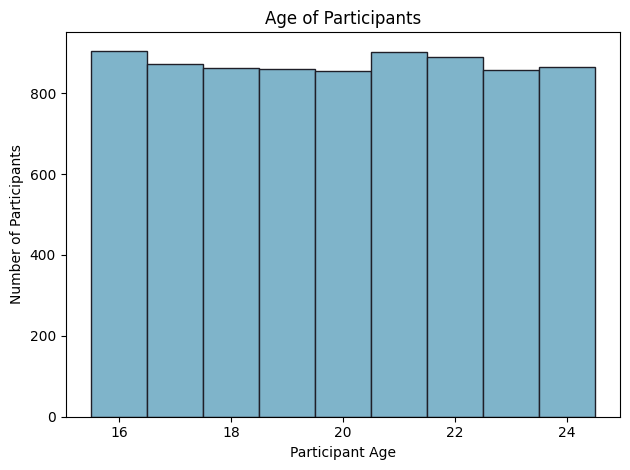

In [378]:
fig, ax = plt.subplots()

ax.hist(dataset['age'], bins=range(16, 26), align='left', color='#7fb4ca', edgecolor='#1f1f28')
ax.set_title('Age of Participants')
ax.set_xlabel('Participant Age')
ax.set_ylabel('Number of Participants')

plt.tight_layout()
plt.show()

As we can see from out chart above the age among our participants is very evenly distributed.

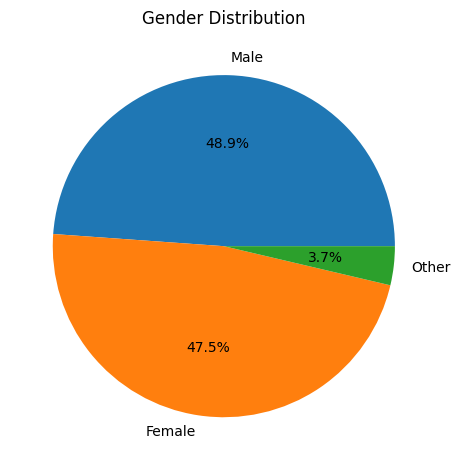

In [379]:
fig, ax = plt.subplots()

genders = dataset['gender'].value_counts()
ax.pie(genders.values, labels=genders.index, autopct="%1.1f%%")
ax.set_title("Gender Distribution")

plt.tight_layout()
plt.show()

As for the gender distribution it's not as even due to people identifying as "Other" is a very small margin in the group. But they still deserve to have their voice heard.

---
---

# Investigation

### Correlation: Gaming addiciton and Faulty grades

For our first dive into the data we have collected, we want to see if there can be found any link between spending too much time playing video games and faulty school performance. To find a pattern we need to visualize a persons average amount of time spent playing games and the status of their current school performance. The best way we can do this is by using a scatter diagram. 

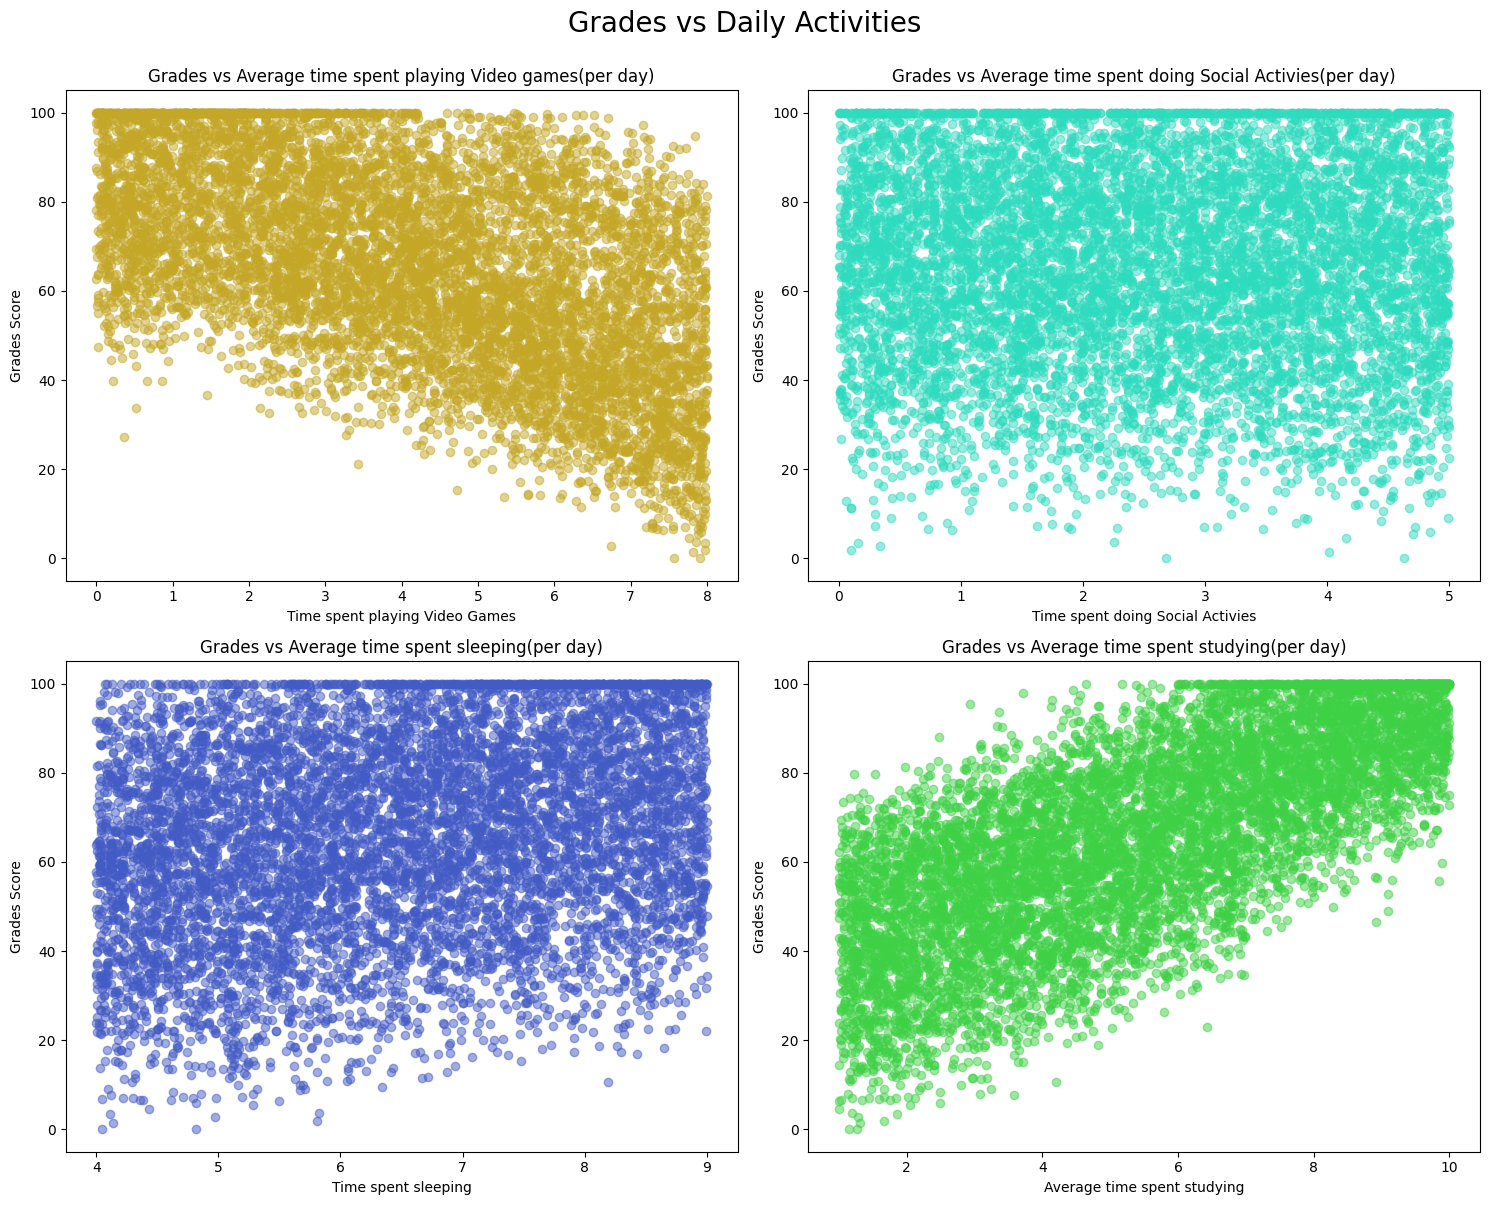

In [380]:
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

ax[0][0].scatter(dataset['gaming_hours'], dataset['grades'], alpha=0.5, color="#c4a726")
ax[0][0].set_title('Grades vs Average time spent playing Video games(per day)')
ax[0][0].set_xlabel('Time spent playing Video Games')
ax[0][0].set_ylabel('Grades Score')

ax[0][1].scatter(dataset['social_activity'], dataset['grades'], alpha=0.5, color="#2ddbbe")
ax[0][1].set_title('Grades vs Average time spent doing Social Activies(per day)')
ax[0][1].set_xlabel('Time spent doing Social Activies')
ax[0][1].set_ylabel('Grades Score')

ax[1][0].scatter(dataset['sleep_hours'], dataset['grades'], alpha=0.5, color="#435bc5")
ax[1][0].set_title('Grades vs Average time spent sleeping(per day)')
ax[1][0].set_xlabel('Time spent sleeping')
ax[1][0].set_ylabel('Grades Score')

ax[1][1].scatter(dataset['study_hours'], dataset['grades'], alpha=0.5, color="#3ed145")
ax[1][1].set_title('Grades vs Average time spent studying(per day)')
ax[1][1].set_xlabel('Average time spent studying')
ax[1][1].set_ylabel('Grades Score')

plt.suptitle("Grades vs Daily Activities", fontsize=20, y=1)
plt.tight_layout()
plt.show()


Despite the very clustered apperance a pattern does emarge. What we can read from the diagrams above are the following, despite having 0 hours spent playing video game a high amount of students that have fairly low grades but as we can see spending upwards of 8 hours of gaming a day does affect grades in some way. BUT, can we assert that is the only reason? According to the data spending time studying also affects the average grade very much as we can see the more time spent studying leads to better grades which feels like a given but the data itself show that plays a part in it. We can also see a very slight affect in sleep affecting ones grades as well but not nearly as much as time spent gaming or time spent studying which i find interesting. The only factor that doesnt seem to affect grades that much is social activities, but the issue there is that the data provided show suggest people dont spend more than 5 hours a day on average socializing which makes not for that great of a source of information.

---

### Battle of the Sexes

Now we wanna answer our next question, what is the gaming patterns between the different genders? For that we need to of course group the data by gender and present it in a way that allows us to get a good idea of IF there is much difference in how they spend their free time. To do that we will use a boxplot diagram.

<function matplotlib.pyplot.show(close=None, block=None)>

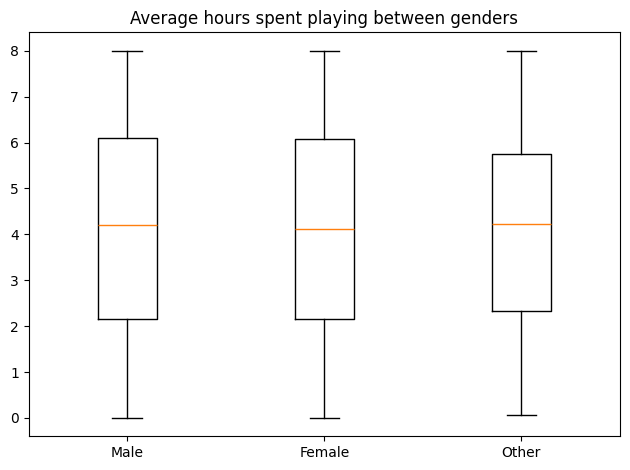

In [393]:
fix, ax = plt.subplots()

males = dataset[dataset['gender'] == 'Male']
females = dataset[dataset['gender'] == 'Female']
other = dataset[dataset['gender'] == 'Other']

ax.boxplot([males['gaming_hours'], females['gaming_hours'], other['gaming_hours']], labels=['Male', 'Female', 'Other'])

ax.set_title('Average hours spent playing between genders')

plt.tight_layout()
plt.show

Now here is a surprise, according to the data represented here it suggest that the average time spent gaming is near identical between genders which seems like a very sensible conclusion. Tho like we noted in the beginning the data we are using was generated and not collected so there is the possibility that the result given here are not accurate to real life but with the data we have, we have to conclude that the average time spent playing video games are the same between genders. But what if we went back and made it possible to see if we can see a pattern between gender and grades?

<function matplotlib.pyplot.show(close=None, block=None)>

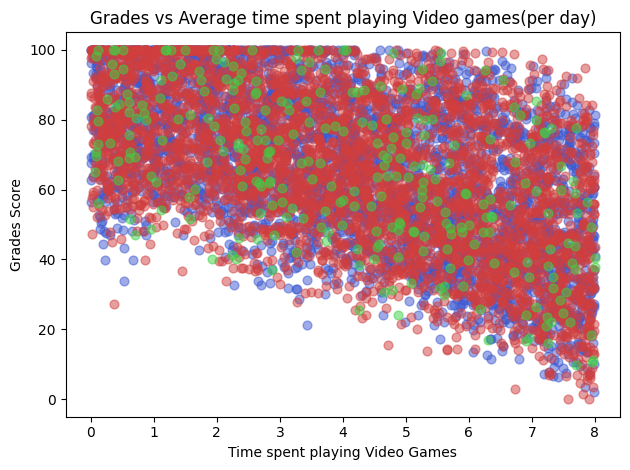

In [399]:
fix, ax = plt.subplots()

colors = {'Male' : "#d13e3e", 'Female' : "#3e59d1", 'Other' : "#3ed145"}
for gender, group in dataset.dropna(subset=['grades']).groupby('gender'):
    ax.scatter(group['gaming_hours'], group['grades'], color=colors[gender], alpha=0.50, s=40, label=gender)
ax.set_title('Grades vs Average time spent playing Video games(per day)')
ax.set_xlabel('Time spent playing Video Games')
ax.set_ylabel('Grades Score')


plt.tight_layout()
plt.show

Nope! No pattern emerges, which forces to draw the conclusion that this data states that there is no difference between the genders when it comes to gaming habits or when it comes to academic performance.

---